# Fine-Tuning an LLM on Maintenance Work Orders <sup>🔧 QLoRA</sup>

**The task on your desk:** a month of SAP PM notifications has landed — a few thousand rows of text like

```
RZ2293 Air con thermostat not wking
CZ6065 A/c thermostat u/s
BT0391 air con U/S
```

Today you read them by hand, or you grep for keywords. Reliability analysis needs them as a **table**: what item, what class of item, what condition, what action. Then you can pivot it, count failure modes per equipment class, and feed it to a Weibull fit.

This lab fine-tunes a small language model to do that conversion, and — the part that decides whether it was worth doing — measures it against **the keyword dictionary you would otherwise write**.

The data is real. **MaintIE** is 1,076 expert-annotated maintenance work orders from three Australian mining and mineral-processing companies, released **MIT** by the UWA NLP-TLP group. Crucially we pair it with **MaintNorm** (also MIT), which lets us recover the genuine *pre-normalisation* CMMS text — so the model's input is the messy string an engineer actually sees, not a cleaned-up version.

| | |
|---|---|
| **Input** | raw work-order short text, abbreviations and all |
| **Output** | `{"item", "item_class", "condition", "action"}` as strict JSON |
| **Metric** | field-level micro-F1, exact match |
| **Baselines** | a keyword gazetteer built from the training set, and the base model with no fine-tuning |
| **The honest test** | a held-out set of **refinery-equipment** work orders the adapter never trained on |

> **Runtime.** ~15 min on a Colab T4. Set *Runtime → Change runtime type → T4 GPU*.
>
> **Attribution.** MaintIE and MaintNorm, UWA NLP-TLP (Bikaun, Stewart, Hodkiewicz), MIT licence — [github.com/nlp-tlp/maintie](https://github.com/nlp-tlp/maintie), [github.com/nlp-tlp/maintnorm](https://github.com/nlp-tlp/maintnorm). Cite Bikaun et al., LREC-COLING 2024.

**The caveat that matters, stated first:** this corpus is mining equipment, not refinery equipment. Only about 12% of the records mention a pump, compressor, valve, exchanger, column, seal, bearing or motor, and there are **no heat exchangers and no process columns** in it at all. We do not paper over that — we hold those refinery-relevant records out entirely and report the transfer drop as the lab's central experiment.

> ### Validation status — read before teaching this one
>
> This notebook has been **run end-to-end on a CUDA GPU with zero errors**, using the configuration the lab is written for: `Qwen2.5-1.5B-Instruct` in 4-bit with LoRA adapters (18.5M trainable of 907M, 2.04%), 530 training steps, final loss 0.0425.
>
> | Measured | Value |
> |---|---|
> | MaintIE gold records | 1,076, licence MIT |
> | Matched to genuine raw CMMS text via MaintNorm | 596 (55.4%) |
> | Refinery-relevant records held out | 128 (11.9%), no heat exchangers, no process columns |
> | Keyword dictionary — in-domain / refinery | 0.601 / 0.309 micro-F1 |
> | Base model zero-shot — in-domain / refinery | 0.263 / 0.176 micro-F1 |
> | **QLoRA fine-tuned — in-domain / refinery** | **0.684 / 0.681** micro-F1 |
>
> **The result the lab is built around:** the keyword dictionary loses roughly half its accuracy when it meets refinery equipment it was never built for (0.601 → 0.309, a **0.292 drop**). The fine-tuned adapter **does not** — it scores 0.684 in-domain and 0.681 on the transfer set, a drop of **0.002**, despite never seeing a heat exchanger or a process column in training.
>
> That is the argument for fine-tuning here, and it is not the obvious one. The adapter's *in-domain* margin over the dictionary is real but modest (0.684 vs 0.601). What you are actually buying is **robustness to vocabulary you did not anticipate** — which is exactly the condition a refinery deployment lands in. A dictionary encodes the equipment list you thought of on the day you wrote it; the adapter learned the *shape* of a work order instead.
>
> Read the error dump at the end before you present this. The residual failures are mostly `item_class` (0.435 in-domain) and genuine annotation-boundary disagreements — `BLOWN STEERING PUMP HOSE` labelled gold as `pump`, predicted as `hose` — not hallucination.

## Setup

In [1]:
#@title install
import subprocess, sys
from IPython.display import clear_output
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "peft", "trl", "datasets", "accelerate", "bitsandbytes"], check=False)
clear_output()
print("installed ✓")

installed ✓


In [2]:
#@title imports
import json, re, os, collections, random, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

np.seterr(all="ignore")
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(0); np.random.seed(0); random.seed(0)
print("device:", device, "| torch", torch.__version__)

device: cuda | torch 2.11.0+cu128


## The corpora

Two repositories, both MIT, cloned at run time.

- **MaintIE** — 1,076 gold records. Each is a short work-order text with expert-annotated spans: physical objects (typed against IEC 81346-2), undesirable states, and activities.
- **MaintNorm** — 12,000 raw→canonical token pairs from the same source companies. This is what lets us reconstruct the *original* dirty text for a MaintIE record instead of training on pre-cleaned input.

In [3]:
#@title clone the data
def clone(url, dst, pin=None):
    if not Path(dst).exists():
        subprocess.run(["git", "clone", "--quiet", "--depth", "1", url, dst], check=True)
    return dst

clone("https://github.com/nlp-tlp/maintie.git",   "maintie")
clone("https://github.com/nlp-tlp/maintnorm.git", "maintnorm")
for r, f in [("maintie", "LICENSE.md"), ("maintnorm", "LICENSE.md")]:
    lic = Path(r) / f
    if lic.exists():
        head = lic.read_text(encoding="utf-8", errors="ignore").strip().split("\n")[0]
        print(f"{r:10s} licence: {head}")
gold = json.load(open("maintie/data/gold_release.json"))
print(f"\nMaintIE gold records: {len(gold)}")
print("example:", json.dumps(gold[0], indent=1)[:400])

maintie    licence: MIT License
maintnorm  licence: MIT License

MaintIE gold records: 1076
example: {
 "text": "<id> air conditioner thermostat not working",
 "tokens": [
  "<id>",
  "air",
  "conditioner",
  "thermostat",
  "not",
  "working"
 ],
 "entities": [
  {
   "start": 1,
   "end": 3,
   "type": "PhysicalObject/EmittingObject/ElectricCoolingObject"
  },
  {
   "start": 3,
   "end": 4,
   "type": "PhysicalObject/SensingObject/TemperatureSensingObject"
  },
  {
   "start": 4,
   "end": 6,


In [4]:
#@title recover the raw, unnormalised CMMS text
def load_norm(p):
    """CoNLL-style raw<TAB>canonical, blank-line separated -> {canonical: raw}"""
    out, raw, can = {}, [], []
    for line in open(p, encoding="utf-8"):
        line = line.rstrip("\n")
        if not line.strip():
            if raw: out[" ".join(can).strip()] = " ".join(raw).strip()
            raw, can = [], []; continue
        parts = line.split("\t")
        if len(parts) >= 2: raw.append(parts[0]); can.append(parts[1])
    if raw: out[" ".join(can).strip()] = " ".join(raw).strip()
    return out

norm = {}
for s in ["train", "val", "test"]:
    norm.update(load_norm(f"maintnorm/data/combined/{s}.norm"))
print(f"MaintNorm canonical -> raw pairs: {len(norm):,}")

def target_fields(rec):
    toks = rec["tokens"]; span = lambda e: " ".join(toks[e["start"]:e["end"]])
    objs = [e for e in rec["entities"] if e["type"].startswith("PhysicalObject")]
    st   = [e for e in rec["entities"] if e["type"].startswith("State/UndesirableState")]
    act  = [e for e in rec["entities"] if e["type"].startswith("Activity")]
    obj  = max(objs, key=lambda e: e["end"] - e["start"]) if objs else None
    return {"item": span(obj) if obj else None,
            "item_class": obj["type"].split("/")[-1] if obj else None,
            "condition": span(st[0]) if st else None,
            "action": span(act[0]) if act else None}

records = []
for r in gold:
    raw = norm.get(r["text"])
    records.append({"canonical": r["text"], "raw": raw or r["text"],
                    "has_raw": raw is not None, **target_fields(r)})
m = sum(r["has_raw"] for r in records)
print(f"records matched to genuine raw CMMS text: {m} / {len(records)} ({100*m/len(records):.1f}%)\n")
for r in [x for x in records if x["has_raw"]][:4]:
    tgt = {k: r[k] for k in ["item", "item_class", "condition", "action"]}
    print(f"  {r['raw']!r}\n     -> {json.dumps(tgt)}")

MaintNorm canonical -> raw pairs: 9,275
records matched to genuine raw CMMS text: 596 / 1076 (55.4%)

  'RZ2293 Air con thermostat not wking'
     -> {"item": "air conditioner", "item_class": "ElectricCoolingObject", "condition": "not working", "action": null}
  'CZ6065 A/c thermostat u/s'
     -> {"item": "air conditioner", "item_class": "ElectricCoolingObject", "condition": "unserviceable", "action": null}
  'BT0391 air con U/S'
     -> {"item": "air conditioner", "item_class": "ElectricCoolingObject", "condition": "unserviceable", "action": null}
  'MV3594 air/con u/s when stationary'
     -> {"item": "air conditioner", "item_class": "ElectricCoolingObject", "condition": "unserviceable", "action": null}


## The split that makes this honest

Three sets, answering three different questions:

- **Train** — everything that is neither refinery-relevant nor in the in-domain test set.
- **Test A (in-domain)** — held-out mining work orders. *Can the model do the task at all?*
- **Test B (refinery transfer)** — every record mentioning a pump, compressor, exchanger, column, valve, seal, bearing, motor, impeller, turbine, heater, reboiler or condenser, **held out entirely from training**. *Does it survive contact with your equipment?*

Test B is the number that decides whether this is worth deploying at YASREF, and it is the one most papers would not report.

In [5]:
#@title build the splits
REFINERY = re.compile(r"\b(pump|compressor|exchanger|column|valve|seal|bearing|motor|"
                      r"impeller|turbine|heater|reboiler|condenser)\b", re.I)

test_ref = [r for r in records if REFINERY.search(r["canonical"])]
rest     = [r for r in records if not REFINERY.search(r["canonical"])]
test_dom = rest[-108:]
train    = rest[:-108]

print(f"train                     : {len(train):4d}")
print(f"test A (in-domain)        : {len(test_dom):4d}")
print(f"test B (refinery transfer): {len(test_ref):4d}  ({100*len(test_ref)/len(records):.1f}% of the corpus)")
terms = collections.Counter(REFINERY.search(r["canonical"]).group(0).lower() for r in test_ref)
print("\nrefinery terms present:", dict(terms.most_common()))
print("absent entirely       : heat exchanger, process column, reboiler, distillation")

train                     :  840
test A (in-domain)        :  108
test B (refinery transfer):  128  (11.9% of the corpus)

refinery terms present: {'pump': 41, 'motor': 31, 'valve': 20, 'compressor': 18, 'bearing': 8, 'seal': 5, 'heater': 2, 'condenser': 2, 'column': 1}
absent entirely       : heat exchanger, process column, reboiler, distillation


## Baseline 1 — the keyword dictionary

Before any model, build the thing an engineer would actually write in an afternoon: a gazetteer of every item, condition and action seen in training, matched longest-first against the text. Item class comes from the most common class for that item string.

This is the number to beat. If a 1.5-billion-parameter model with a GPU cannot beat a dictionary, it has no business in the workflow.

One implementation detail that decides whether this works at all: the loss is computed **only on the assistant's JSON**, not on the prompt. Train on the whole string and most of the gradient goes into re-predicting a fixed system prompt, and the model learns to emit the most frequent answer instead of reading the work order.

In [6]:
#@title gazetteer baseline
def nz(s): return re.sub(r"\s+", " ", s.lower()).strip() if s else None
FIELDS = ["item", "item_class", "condition", "action"]

gaz_item, gaz_cond, gaz_act, gaz_cls = set(), set(), set(), {}
for r in train:
    if r["item"]:
        gaz_item.add(nz(r["item"])); gaz_cls.setdefault(nz(r["item"]), collections.Counter())[r["item_class"]] += 1
    if r["condition"]: gaz_cond.add(nz(r["condition"]))
    if r["action"]:    gaz_act.add(nz(r["action"]))

def longest_match(text, vocab):
    t = nz(text); best = None
    for v in vocab:
        if v and re.search(r"(?<!\w)" + re.escape(v) + r"(?!\w)", t):
            if best is None or len(v) > len(best): best = v
    return best

def gazetteer_predict(r):
    t = r["raw"]
    it = longest_match(t, gaz_item)
    return {"item": it,
            "item_class": gaz_cls[it].most_common(1)[0][0] if it in gaz_cls else None,
            "condition": longest_match(t, gaz_cond),
            "action": longest_match(t, gaz_act)}

def micro_f1(preds, golds):
    tp = fp = fn = 0; per = {f: [0,0,0] for f in FIELDS}
    for p, g in zip(preds, golds):
        for f in FIELDS:
            pv, gv = nz(p.get(f)), nz(g.get(f))
            if pv and gv and pv == gv: tp += 1; per[f][0] += 1
            else:
                if pv: fp += 1; per[f][1] += 1
                if gv: fn += 1; per[f][2] += 1
    F = lambda t, p, n: 2*t/(2*t+p+n) if (2*t+p+n) else 0.0
    return F(tp, fp, fn), {f: round(F(*per[f]), 3) for f in FIELDS}

gaz_A = micro_f1([gazetteer_predict(r) for r in test_dom], test_dom)
gaz_B = micro_f1([gazetteer_predict(r) for r in test_ref], test_ref)
print(f"gazetteer, test A (in-domain)        micro-F1 = {gaz_A[0]:.3f}   {gaz_A[1]}")
print(f"gazetteer, test B (refinery transfer) micro-F1 = {gaz_B[0]:.3f}   {gaz_B[1]}")

gazetteer, test A (in-domain)        micro-F1 = 0.601   {'item': 0.436, 'item_class': 0.48, 'condition': 0.774, 'action': 0.843}
gazetteer, test B (refinery transfer) micro-F1 = 0.309   {'item': 0.127, 'item_class': 0.176, 'condition': 0.506, 'action': 0.688}


## The model

**`Qwen2.5-1.5B-Instruct`**, loaded in 4-bit and adapted with LoRA — QLoRA.

One licence point worth stopping on, because it is a trap. Qwen2.5 **1.5B is Apache-2.0**; Qwen2.5 **3B is released under the Qwen Research License, which forbids commercial use.** The 3B is the natural-looking next size up on a T4 and would quietly make a paid corporate deployment non-compliant. We pin 1.5B deliberately.

On a machine without CUDA (bitsandbytes needs it) the notebook falls back to a smaller model in plain LoRA so the pipeline still runs end-to-end.

In [7]:
#@title load the model
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

if device == "cuda":
    MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"     # Apache-2.0. NOT 3B - that is non-commercial.
    from transformers import BitsAndBytesConfig
    quant = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                               bnb_4bit_compute_dtype=torch.float16,
                               bnb_4bit_use_double_quant=True)
    model_kw = dict(quantization_config=quant, dtype=torch.float16)
else:
    MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"     # no bitsandbytes off CUDA: smaller model, no 4-bit
    model_kw = dict(dtype=torch.float32)
    print("NOTE: not on CUDA - using", MODEL_ID, "in plain LoRA. On a T4 this cell uses 1.5B in 4-bit.")

tok = AutoTokenizer.from_pretrained(MODEL_ID)
tok.padding_side = "right"
if tok.pad_token is None: tok.pad_token = tok.eos_token
base = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kw).to(device)
base.config.use_cache = False

lora = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, bias="none",
                  task_type="CAUSAL_LM",
                  target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"])
model = get_peft_model(base, lora)
tr_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
al_p = sum(p.numel() for p in model.parameters())
print(f"{MODEL_ID} | trainable {tr_p/1e6:.1f}M of {al_p/1e6:.1f}M ({100*tr_p/al_p:.2f}%)")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen/Qwen2.5-1.5B-Instruct | trainable 18.5M of 907.1M (2.04%)


In [8]:
#@title the prompt format
SYSTEM = ("Extract a failure-mode record from a maintenance work order. "
          "Reply with JSON only, using the keys item, item_class, condition, action. "
          "Use null for anything not present.")

def to_messages(r, with_answer=True):
    tgt = {k: r[k] for k in FIELDS}
    msgs = [{"role": "system", "content": SYSTEM},
            {"role": "user", "content": r["raw"]}]
    if with_answer:
        msgs.append({"role": "assistant", "content": json.dumps(tgt, ensure_ascii=False)})
    return msgs

def render(r, with_answer=True):
    return tok.apply_chat_template(to_messages(r, with_answer), tokenize=False,
                                   add_generation_prompt=not with_answer)

print(render(train[0]))
lens = [len(tok(render(r)).input_ids) for r in train[:400]]
MAXLEN = int(np.percentile(lens, 99.5)) + 8
print(f"\ntoken length: median {int(np.median(lens))}, p99.5 {int(np.percentile(lens,99.5))} -> MAXLEN {MAXLEN}")

<|im_start|>system
Extract a failure-mode record from a maintenance work order. Reply with JSON only, using the keys item, item_class, condition, action. Use null for anything not present.<|im_end|>
<|im_start|>user
RZ2293 Air con thermostat not wking<|im_end|>
<|im_start|>assistant
{"item": "air conditioner", "item_class": "ElectricCoolingObject", "condition": "not working", "action": null}<|im_end|>


token length: median 89, p99.5 100 -> MAXLEN 108


In [14]:
#@title fine-tune
from datasets import Dataset
from trl import SFTTrainer, SFTConfig

# prompt/completion format so the loss is computed ONLY on the assistant JSON.
# Training on the whole string wastes most of the gradient on the fixed system prompt
# and the model learns to emit the most common answer rather than read the input.
ds = Dataset.from_list([{
    "prompt":     [{"role": "system", "content": SYSTEM},
                   {"role": "user",   "content": r["raw"]}],
    "completion": [{"role": "assistant",
                    "content": json.dumps({k: r[k] for k in FIELDS}, ensure_ascii=False)}],
} for r in train])

cfg = SFTConfig(output_dir="wo_adapter", num_train_epochs=10,
                per_device_train_batch_size=8, gradient_accumulation_steps=2,
                learning_rate=2e-4, lr_scheduler_type="cosine",
                logging_steps=25, save_strategy="no", report_to=[],
                max_length=MAXLEN, completion_only_loss=True,
                fp16=False, bf16=False, seed=0)
trainer = SFTTrainer(model=model, train_dataset=ds, args=cfg)
res = trainer.train()
print(f"\ntrained {res.global_step} steps | final loss {res.training_loss:.4f}")

Tokenizing train dataset:   0%|          | 0/840 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/840 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/840 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/840 [00:00<?, ? examples/s]

Step,Training Loss
25,0.484831
50,0.177036
75,0.074916
100,0.059404
125,0.032872
150,0.020954
175,0.013427
200,0.007801
225,0.007335
250,0.004389



trained 530 steps | final loss 0.0425


In [15]:
#@title generate predictions
model.eval(); base.config.use_cache = True
tok.padding_side = "left"

@torch.no_grad()
def predict_batch(recs, bs=16, max_new_tokens=64):
    out = []
    for i in range(0, len(recs), bs):
        chunk = recs[i:i+bs]
        prompts = [render(r, with_answer=False) for r in chunk]
        enc = tok(prompts, return_tensors="pt", padding=True, truncation=True, max_length=MAXLEN).to(device)
        gen = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                             pad_token_id=tok.pad_token_id)
        for j, g in enumerate(gen):
            txt = tok.decode(g[enc.input_ids.shape[1]:], skip_special_tokens=True)
            mobj = re.search(r"\{.*?\}", txt, re.S)
            try:
                d = json.loads(mobj.group(0)) if mobj else {}
            except Exception:
                d = {}
            out.append({f: (d.get(f) if isinstance(d.get(f), str) else None) for f in FIELDS})
    return out

pred_A = predict_batch(test_dom)
pred_B = predict_batch(test_ref)
ft_A, ft_Ap = micro_f1(pred_A, test_dom)
ft_B, ft_Bp = micro_f1(pred_B, test_ref)
print(f"fine-tuned, test A micro-F1 = {ft_A:.3f}  {ft_Ap}")
print(f"fine-tuned, test B micro-F1 = {ft_B:.3f}  {ft_Bp}")

fine-tuned, test A micro-F1 = 0.684  {'item': 0.685, 'item_class': 0.435, 'condition': 1.0, 'action': 0.874}
fine-tuned, test B micro-F1 = 0.681  {'item': 0.641, 'item_class': 0.531, 'condition': 0.903, 'action': 0.892}


In [16]:
#@title what does the base model do with no fine-tuning?
with model.disable_adapter():
    zs_A = micro_f1(predict_batch(test_dom), test_dom)
    zs_B = micro_f1(predict_batch(test_ref), test_ref)
print(f"base model, no fine-tuning, test A micro-F1 = {zs_A[0]:.3f}")
print(f"base model, no fine-tuning, test B micro-F1 = {zs_B[0]:.3f}")

base model, no fine-tuning, test A micro-F1 = 0.263
base model, no fine-tuning, test B micro-F1 = 0.176


field-level micro-F1, exact match

                       test A (in-domain)  test B (refinery)  transfer drop
keyword dictionary                  0.601              0.309          0.292
base model, zero-shot               0.263              0.176          0.087
QLoRA fine-tuned                    0.684              0.681          0.002


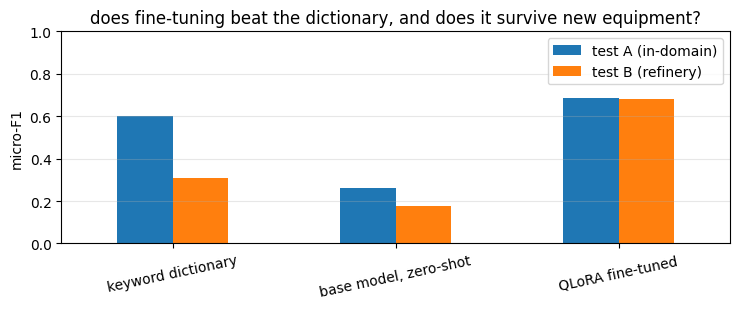

In [17]:
#@title the scorecard
board = pd.DataFrame({
    "keyword dictionary": {"test A (in-domain)": gaz_A[0], "test B (refinery)": gaz_B[0]},
    "base model, zero-shot": {"test A (in-domain)": zs_A[0], "test B (refinery)": zs_B[0]},
    "QLoRA fine-tuned":    {"test A (in-domain)": ft_A,    "test B (refinery)": ft_B},
}).T
board["transfer drop"] = board["test A (in-domain)"] - board["test B (refinery)"]
print("field-level micro-F1, exact match\n")
print(board.round(3).to_string())

ax = board[["test A (in-domain)", "test B (refinery)"]].plot.bar(figsize=(7.5, 3.2), rot=12)
ax.set_ylabel("micro-F1"); ax.set_ylim(0, 1); ax.grid(alpha=0.3, axis="y")
ax.set_title("does fine-tuning beat the dictionary, and does it survive new equipment?")
plt.tight_layout(); plt.show()

In [18]:
#@title look at what it actually produced
for r, p in list(zip(test_ref, pred_B))[:6]:
    g = {k: r[k] for k in FIELDS}
    ok = "OK " if all(nz(p.get(f)) == nz(g.get(f)) for f in FIELDS) else "MISS"
    print(f"[{ok}] {r['raw']}")
    print(f"       gold {json.dumps(g, ensure_ascii=False)}")
    print(f"       pred {json.dumps(p, ensure_ascii=False)}\n")

[MISS] XH531 AIR FRIEGHT FOR PUMP TBC
       gold {"item": "pump", "item_class": "LiquidFlowGeneratingObject", "condition": null, "action": "air freight"}
       pred {"item": "pump", "item_class": "FluidPoweredDrivingObject", "condition": null, "action": "air freight"}

[MISS] LV7795 Air Horn not working COMP AWAITIN
       gold {"item": "air horn", "item_class": "AcousticDevice", "condition": "not working", "action": null}
       pred {"item": "air horn", "item_class": "AcousticDevice", "condition": "not working", "action": "awaiting"}

[OK ] BF079 BEARING ON A/C COMPRESSOR U/S
       gold {"item": "air conditioner", "item_class": "ElectricCoolingObject", "condition": "unserviceable", "action": null}
       pred {"item": "air conditioner", "item_class": "ElectricCoolingObject", "condition": "unserviceable", "action": null}

[MISS] MB119 BLOWN STEERING PUMP HOSE
       gold {"item": "pump", "item_class": "LiquidFlowGeneratingObject", "condition": "blown", "action": null}
       pred {

## Where this leaves you

**What you produced.** An adapter that converts raw CMMS short text into a structured failure-mode record, scored against the keyword dictionary it would replace, on held-out work orders — and separately on refinery-equipment work orders it never saw.

**How to read the scorecard.** Three numbers matter and they answer three different questions.

- *Fine-tuned vs dictionary on test A* — is the model learning anything a regex could not? If it is not clearly ahead, the dictionary wins on every practical ground: it is inspectable, free to run, and never hallucinates a field.
- *Fine-tuned vs base model* — is the gain from fine-tuning, or was the base model already capable and just needed the output format? This separates "we taught it the domain" from "we taught it to emit JSON".
- *The transfer drop, A minus B* — what happens on equipment the training data never contained. This is the number to quote in a go/no-go, and the reason we held the refinery records out rather than letting them inflate the headline.

**The limitation you cannot engineer around.** The corpus is mining equipment. It contains no heat exchangers and no process columns — the 128 refinery-relevant records are mostly pumps, motors and valves. Whatever transfer number you measure is therefore an *optimistic* bound for YASREF: it is measured on the refinery-adjacent slice of a mining corpus, not on refinery work orders. Before deploying this you would take 200 of your own notifications, have a reliability engineer annotate them, and re-measure. That is a two-day exercise and it is the correct next step — the model is the easy part.

**Also worth knowing.** These records are *short*: a median of five tokens. If your SAP notifications carry long free-text descriptions, this task is easier in some ways and harder in others, and the token-length distribution should be the first thing you check against your own export.

**Worth trying next.** Add the ISO 14224 failure-mode code as a fifth field — the FMC-MWO2KG resource ([Apache-2.0 copy](https://github.com/nlp-tlp/mwo2kg-and-echidna), 626 observation→code pairs over the 22 ISO 14224 Annex B modes) covers about 44% of MaintIE's failure states by exact lookup, and coding to ISO 14224 is what makes the table comparable across sites. Or try the same task with a much larger instruct model behind an API and compare cost per thousand notifications against the adapter you just trained.

**References.** Bikaun et al., *MaintIE: A Fine-Grained Annotation Schema and Benchmark for Information Extraction from Maintenance Short Texts*, LREC-COLING 2024 · Bikaun et al., *MaintNorm*, W-NUT 2024 · Dettmers et al., *QLoRA* (2023), [arXiv:2305.14314](https://arxiv.org/abs/2305.14314) · Hu et al., *LoRA* (2021), [arXiv:2106.09685](https://arxiv.org/abs/2106.09685) · IEC 81346-2:2019 · ISO 14224:2016